# Tracking Error Bound Generation


In [8]:
import numpy as np
from tqdm import tqdm

from lib.algorithms.unconstrained import gradient_descent, nesterov, triple_momentum
from lib.analysis.run_solver import static_IQC_rho_sweep, var_IQC_rho_sweep
from lib.analysis.polytope import consistent_polytope_nd, visualize
from lib.simulation.objectives import PeriodicExample2D, QP
from lib.simulation.simulate import simulate
from lib.utils.plot import plot_bounds_figure

## Step 1: Define the objective, initial condition, and consistent polytope

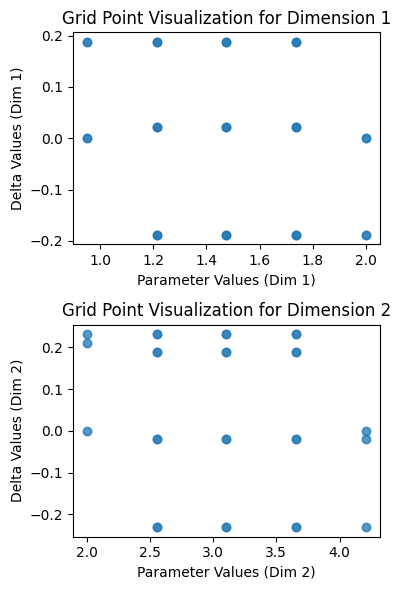

In [9]:
# Choose objective and algorithm
obj = PeriodicExample2D(omega=0.1)
x0  = np.ones((obj.nx, 1)) * 5.0

# estimate consistent (m,L)-polytope for that objective
L_min, L_max, m_min, m_max, delta_L_max, delta_m_max, delta_L_min, delta_m_min = obj.estimate_sector_variation(T_probe=200)

n_grid = 5
params = np.vstack((np.linspace(m_min, m_max, n_grid), np.linspace(L_min, L_max, n_grid)))
polytope = consistent_polytope_nd(
            params, 
            np.array([delta_m_min, delta_L_min]), 
            np.array([delta_m_max, delta_L_max]), 
            step_size=(m_max - m_min)/n_grid
           )

visualize(polytope)

## Step 2: Define optimization algorithm and compute tracking certificates

In [ ]:
### select algorithm to analyze
algo_def = gradient_descent
# algo_def = lambda m, L: gradient_descent(m, L, K=2)
# algo_def = nesterov
# algo_def = triple_momentum

### get certificates (static IQC)
certificates_sIQC = static_IQC_rho_sweep(algo_def, polytope, rho_step=0.01)

### get certificates (variational IQC)
certificates_vIQC = var_IQC_rho_sweep(algo_def, polytope, rho_step=0.01)


Static IQC: compute certificates over rho grid:  43%|████▎     | 43/101 [01:06<01:32,  1.60s/it]

## Step 3: Simulate, compute tracking error, and compare to certified tracking upper bounds


In [ ]:
T_sim = 200

ranked_bounds_sIQC = list()
ranked_bounds_vIQC = list()

# static IQC
for certificate in tqdm(certificates_sIQC, desc='Static IQC: computing bounds...'):
        tracking_error, error_bound = simulate(algo_def, obj, x0, T_sim, certificate)
        
        score = float(np.sum(error_bound))
        ranked_bounds_sIQC.append((score, error_bound, certificate))

# variational IQC
for certificate in tqdm(certificates_vIQC, desc='Variational IQC: computing bounds...'):
        tracking_error, error_bound = simulate(algo_def, obj, x0, T_sim, certificate)
        
        score = float(np.sum(error_bound))
        ranked_bounds_vIQC.append((score, error_bound, certificate))

# sort and select top 5 error bounds
ranked_bounds_sIQC.sort(key=lambda item: item[0])
ranked_bounds_vIQC.sort(key=lambda item: item[0])

ranked_bounds_sIQC = ranked_bounds_sIQC[0:5]
ranked_bounds_vIQC = ranked_bounds_vIQC[0:5]

Variational IQC: computing bounds...: 100%|██████████| 24/24 [00:11<00:00,  2.09it/s]


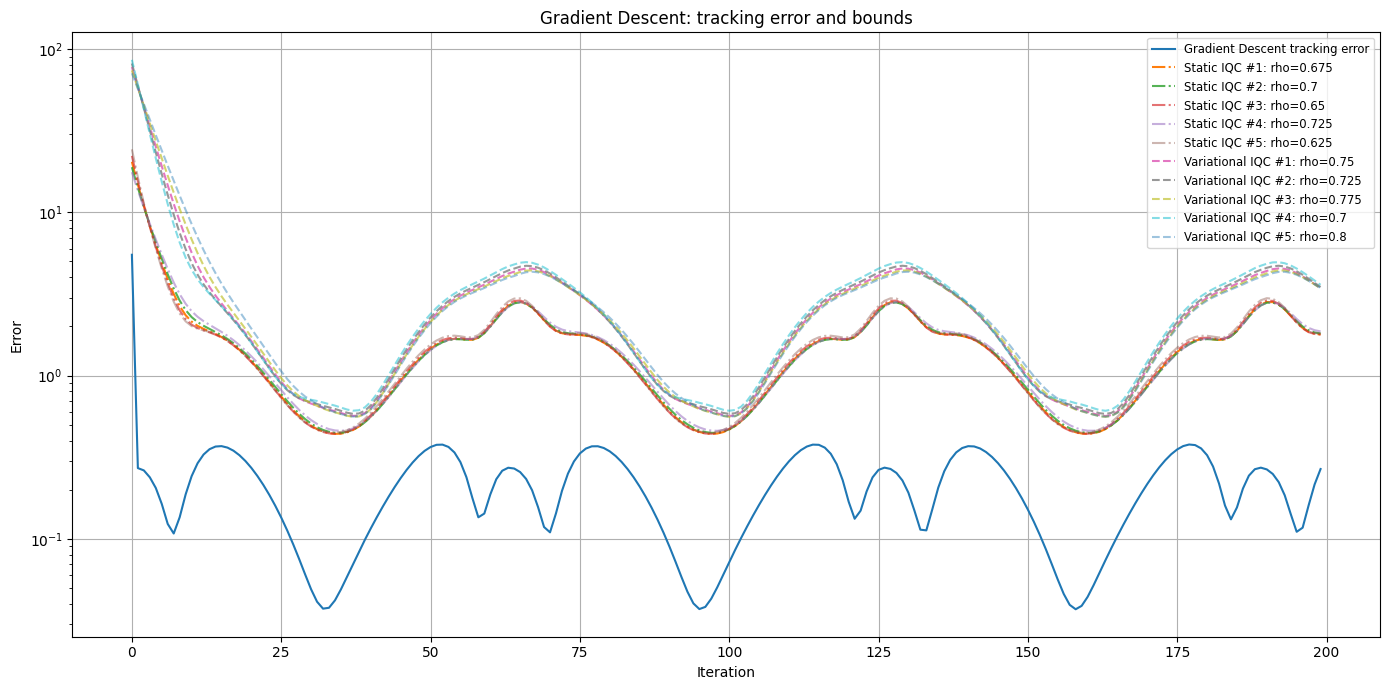

In [ ]:
plot_bounds_figure(
    tracking_error=tracking_error,
    sIQC_bounds=ranked_bounds_sIQC,
    vIQC_bounds=ranked_bounds_vIQC,
    algo_name='Gradient Descent',
    save_plots=False,
)